In [83]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import scipy.special as sp
from scipy import stats

L = 64 #number of lattice points in each dimension
size = L*L #total number of lattice points
J = 1.0  #Coupling Coefficient
N = 100 #number of monte-carlo steps for data collection
Neq = 50 #number of MCS for equilibration
Nt = 50 #number of temperatures sampled
Temps = np.linspace(.01,15,Nt)

#Data Collection
M_t = np.zeros(N) #magnetization
E_t = np.zeros(N) #energy per spin/lattice point
E2_t = np.zeros(N) #E^2 per spin
s_T = []
M_T = np.zeros(Nt)
E_T = np.zeros(Nt)
Cv_T = np.zeros(Nt)

#Iterate over Temps
Tcounter = 0
for T in Temps:
    #Begin in Random Initial State
    state = np.random.choice([-1,1],(L,L))
    state_i = state.copy()
    #Begin Iteration of MCS (monte-carlo steps)
    for n_out in range(N+Neq):
        if n_out >= Neq:
            #compute and store magnetization
            M_t[n_out-Neq] = np.sum(state)/size
            #compute and store energy per spin
            E_t[n_out-Neq] = -J*np.sum(state*(np.roll(state,1,0)+np.roll(state,1,1)))/size
            #compute and store E^2 per spin
            E2_t[n_out-Neq] = E_t[n_out-Neq]**2
        #For each MCS, attempt flipping one spin for every lattice point
        randxy = np.random.randint(0,L,(size,2))
        for n_in in range(size):
            #choose a random lattice point
            xpos = randxy[n_in,0]
            xp = xpos+1
            if xp == L:
                xp = 0
            xm = xpos-1
            ypos = randxy[n_in,1]
            yp = ypos+1
            if yp == L:
                yp = 0
            ym = ypos-1
            #calculate change in energy of prospective flip
            dU = 2*J*state[xpos,ypos]*(state[xp,ypos] + state[xm,ypos] + state[xpos,yp] + state[xpos,ym])
            #decide whether to flip
            if dU <= 0:
                state[xpos,ypos] *= -1
            elif np.random.rand() < np.exp(-dU/T):
                state[xpos,ypos] *= -1
    M_T[Tcounter] = stats.mode(np.abs(M_t),axis=None)[0]
    E_T[Tcounter] = np.sum(E_t)/N
    Cv_T[Tcounter] = ((np.sum(E2_t)/N)-(E_T[Tcounter]**2))/(T**2)
    state_f = state.copy()
    s_T.append((state_i,state_f))
    Tcounter += 1

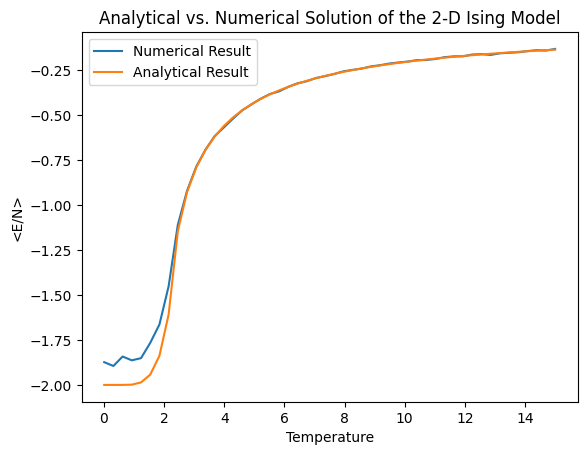

In [84]:
#Analytical Solution:
def analyticalE(T):
    k = (2*np.sinh(2*J/T))/(np.cosh(2*J/T))**2
    K = sp.ellipk(k**2)
    return (-J/np.tanh(2*J/T))*(1+(2/np.pi)*(-1+2*(np.tanh(2*J/T))**2)*K)
exactE_T = np.array([analyticalE(T) for T in Temps])
#Plot <E/N>(T)
plt.plot(Temps,E_T, label='Numerical Result')
plt.plot(Temps, exactE_T, label='Analytical Result')
plt.title("Analytical vs. Numerical Solution of the 2-D Ising Model")
#plt.xscale('log')
plt.xlabel("Temperature")
plt.ylabel("<E/N>")
plt.legend()
#plt.savefig(f'Figures/2D/2D-EnergyComparison.jpg')
plt.show()

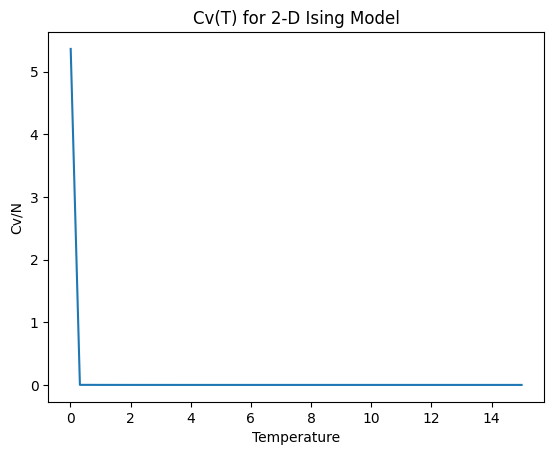

In [85]:
#Plot Cv(T)/N
plt.plot(Temps,Cv_T, label='Numerical Result')
#plt.plot(Temps, exactCv_T, label='Analytical Result')
plt.title("Cv(T) for 2-D Ising Model")
#plt.xscale('log')
plt.xlabel("Temperature")
plt.ylabel("Cv/N")
#plt.legend()
#plt.savefig(f'Figures/1D/1D-EnergyComparison.jpg')
plt.show()

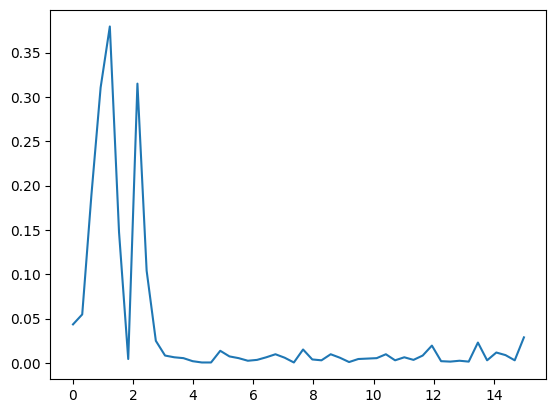

In [86]:
#Plot <M>(T)
plt.plot(Temps,M_T)
#plt.xscale('log')
plt.show()

Temperature: 0.01


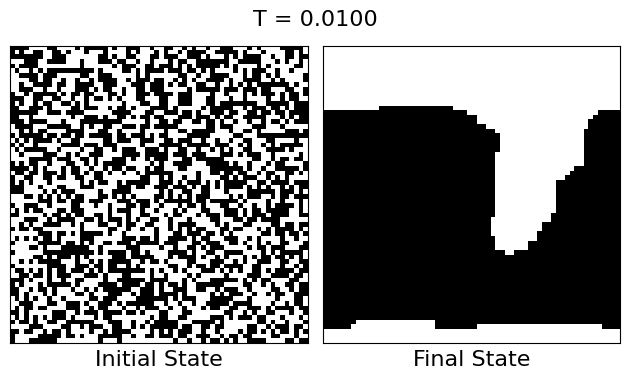

Temperature: 0.3159183673469388


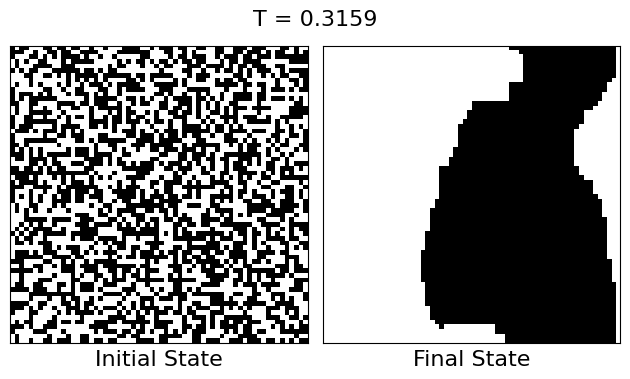

Temperature: 0.6218367346938776


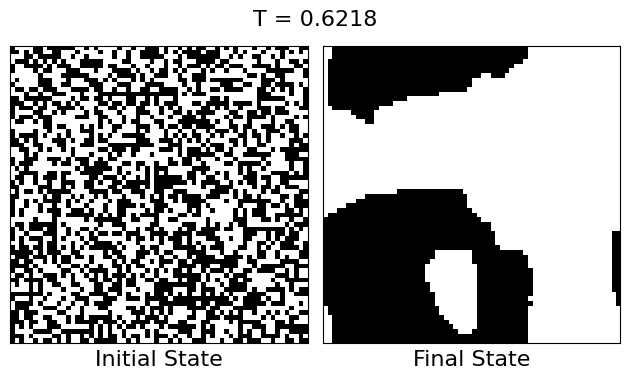

Temperature: 0.9277551020408163


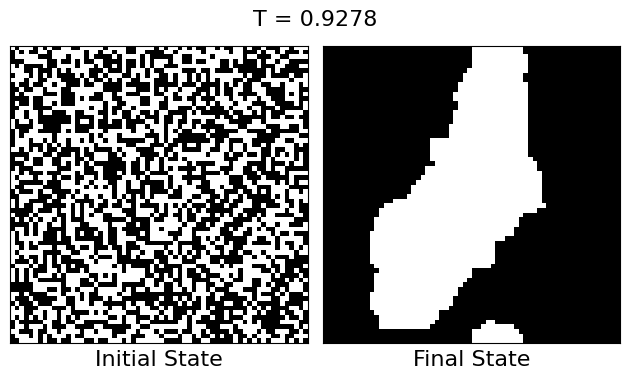

Temperature: 1.2336734693877551


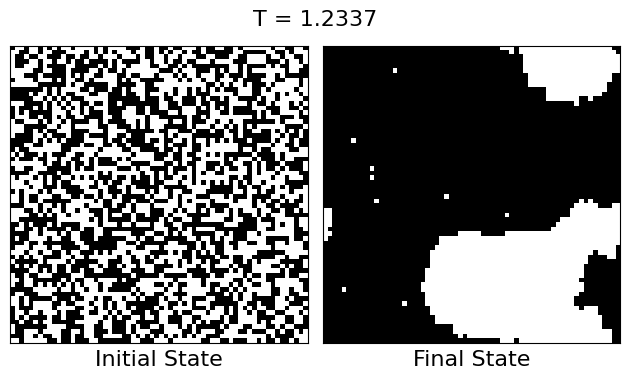

Temperature: 1.539591836734694


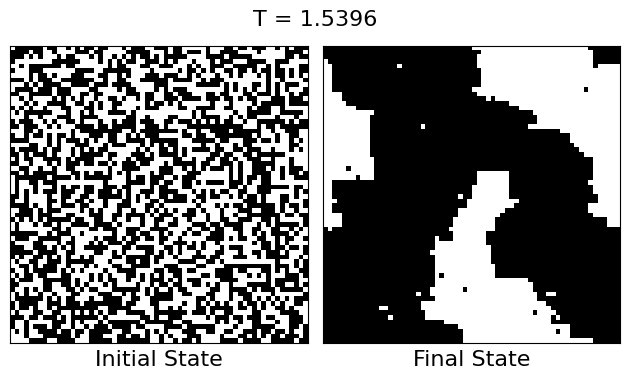

Temperature: 1.8455102040816327


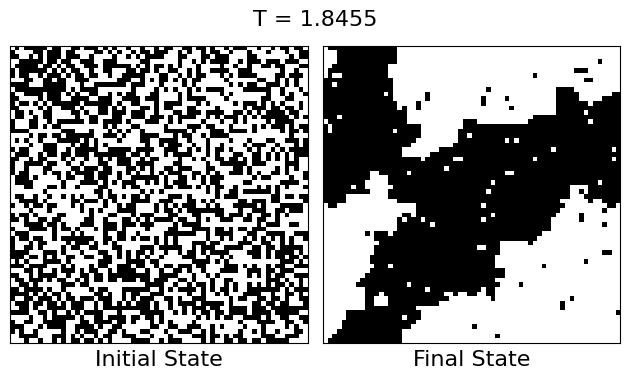

Temperature: 2.1514285714285712


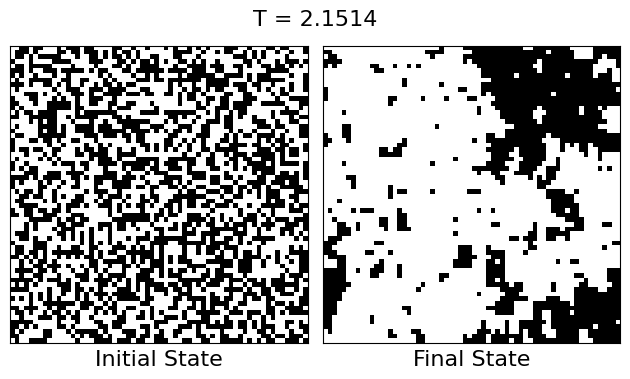

Temperature: 2.45734693877551


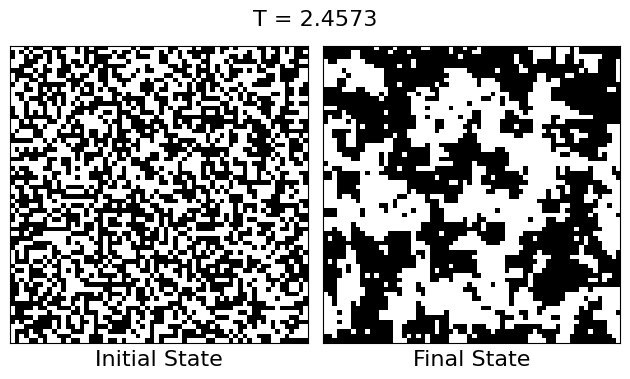

Temperature: 2.763265306122449


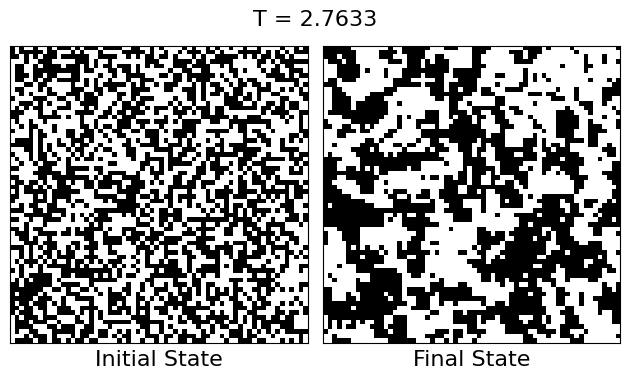

Temperature: 3.0691836734693876


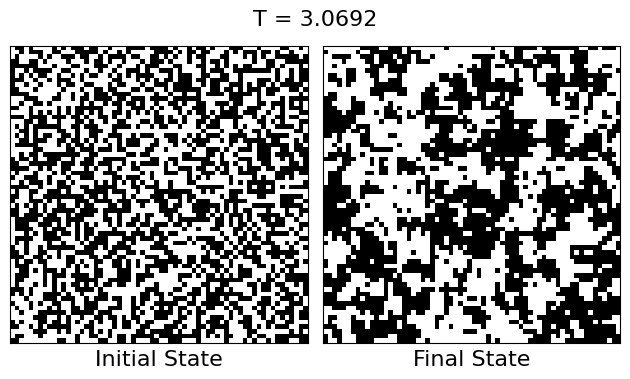

Temperature: 3.3751020408163264


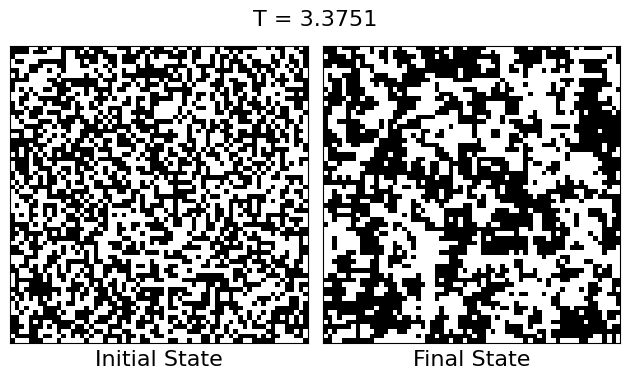

Temperature: 3.681020408163265


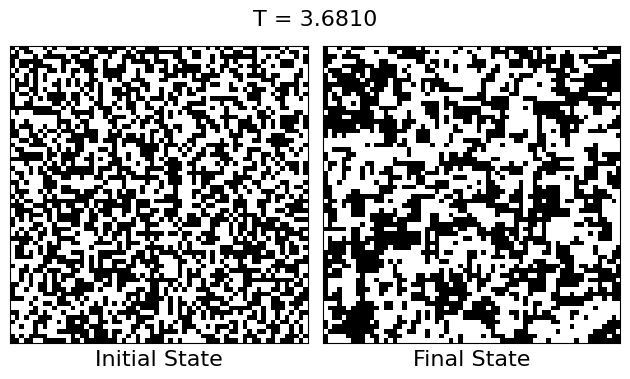

Temperature: 3.986938775510204


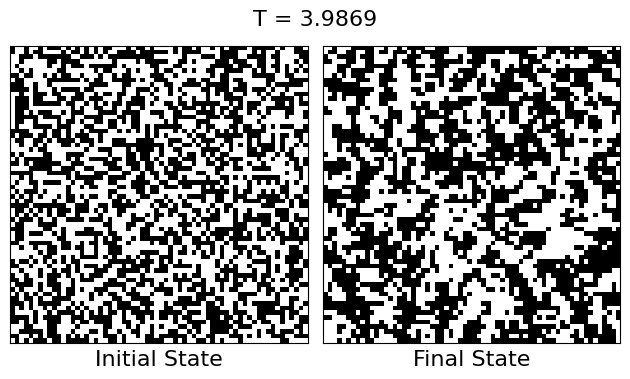

Temperature: 4.292857142857143


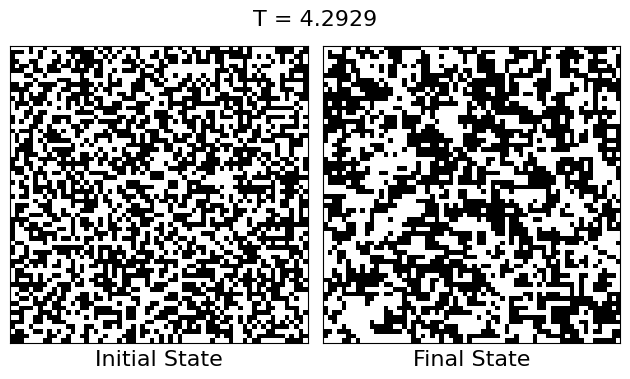

Temperature: 4.5987755102040815


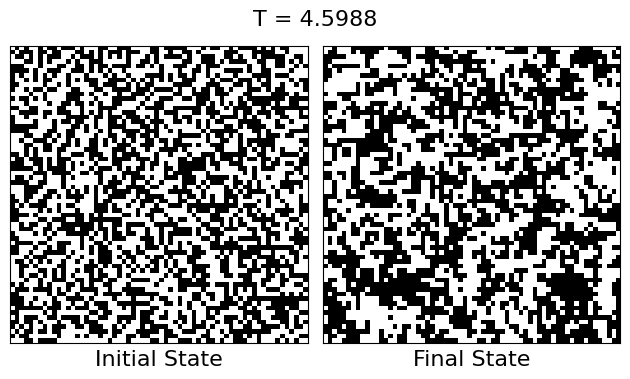

Temperature: 4.90469387755102


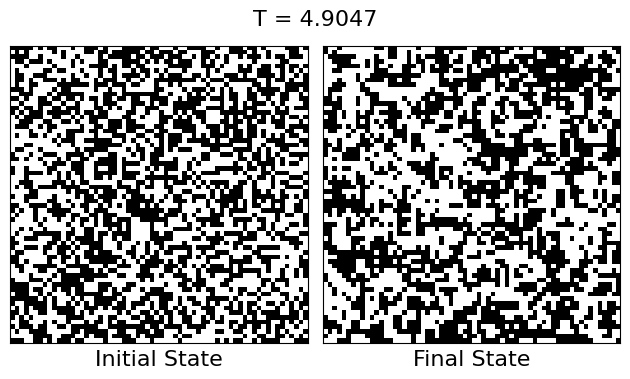

Temperature: 5.210612244897959


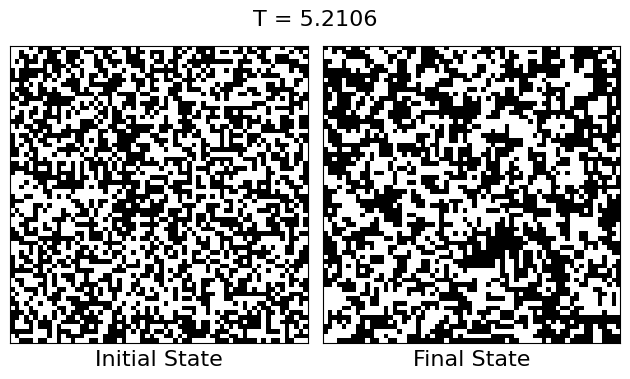

Temperature: 5.516530612244898


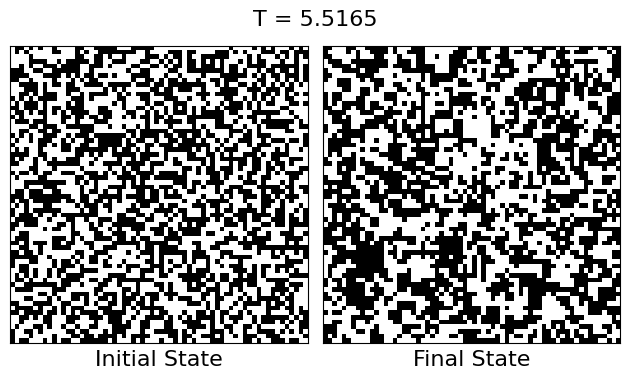

Temperature: 5.822448979591837


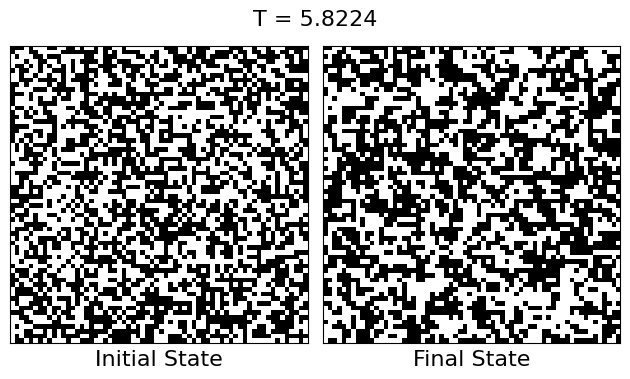

Temperature: 6.128367346938775


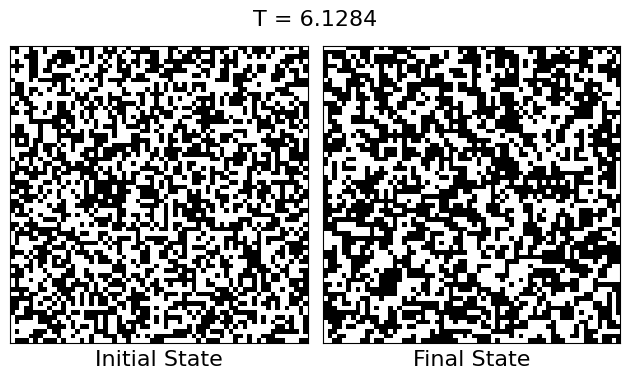

Temperature: 6.434285714285714


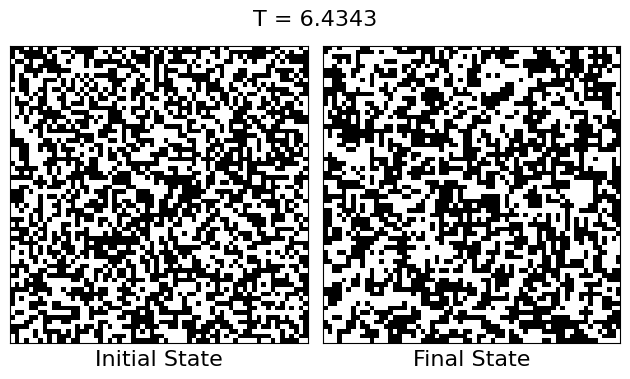

Temperature: 6.740204081632653


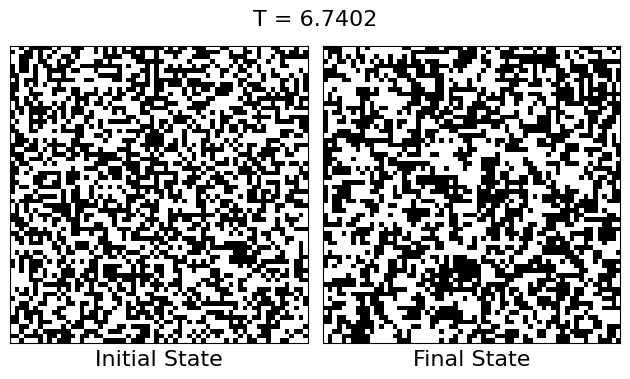

Temperature: 7.046122448979592


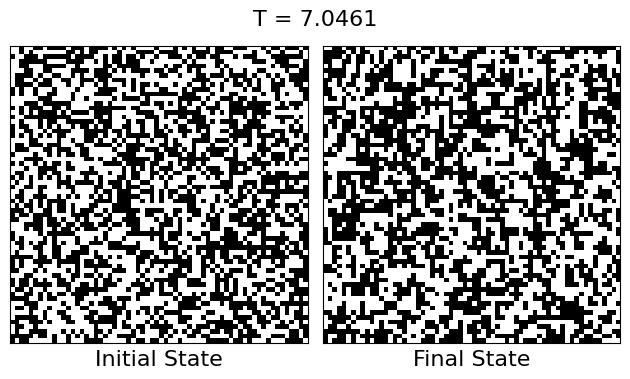

Temperature: 7.3520408163265305


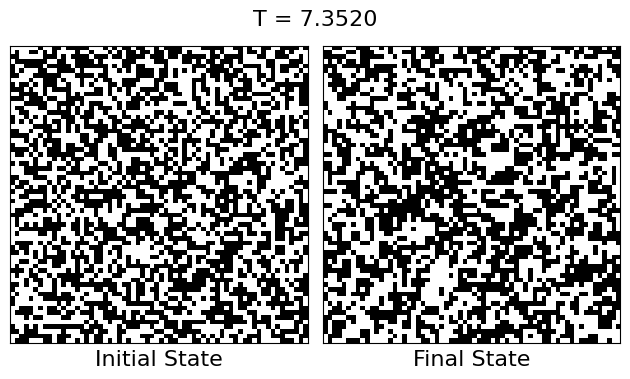

Temperature: 7.657959183673469


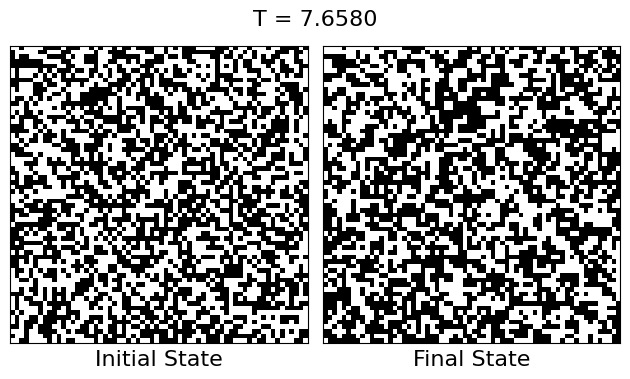

Temperature: 7.963877551020408


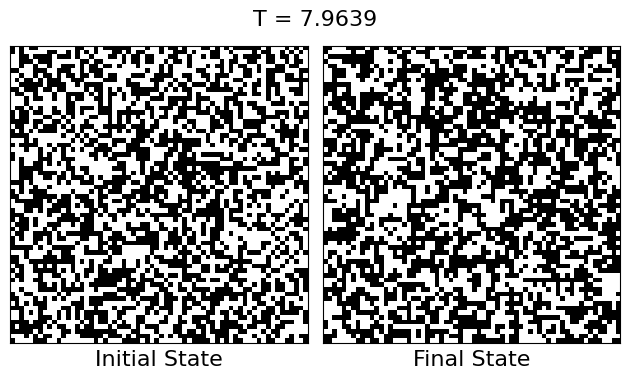

Temperature: 8.269795918367347


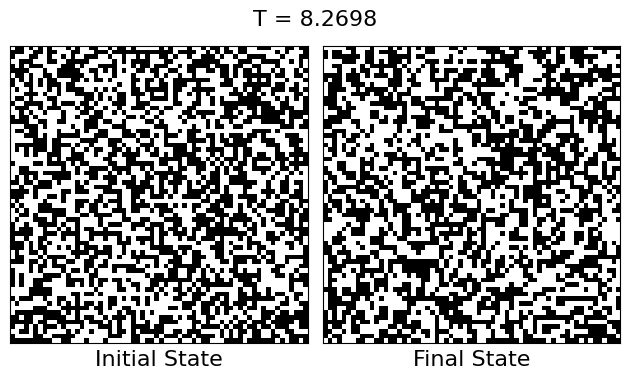

Temperature: 8.575714285714286


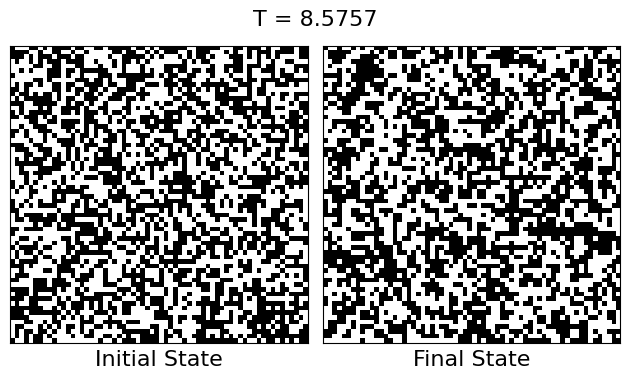

Temperature: 8.881632653061224


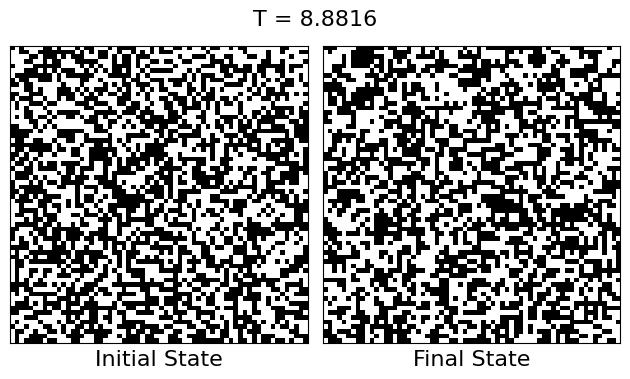

Temperature: 9.187551020408163


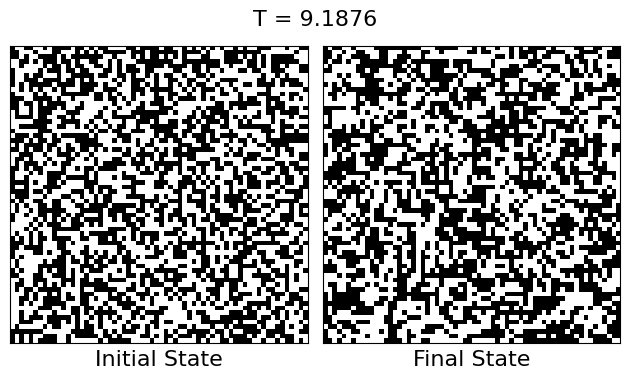

Temperature: 9.493469387755102


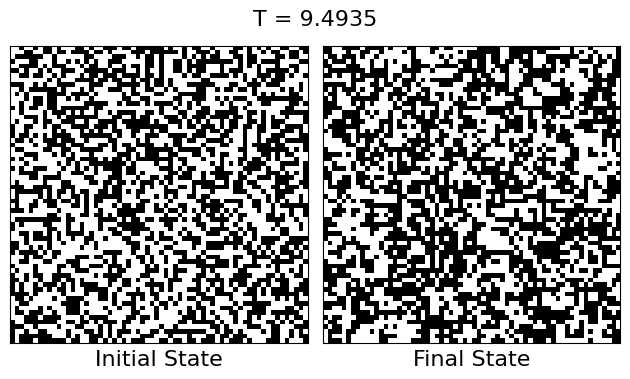

Temperature: 9.79938775510204


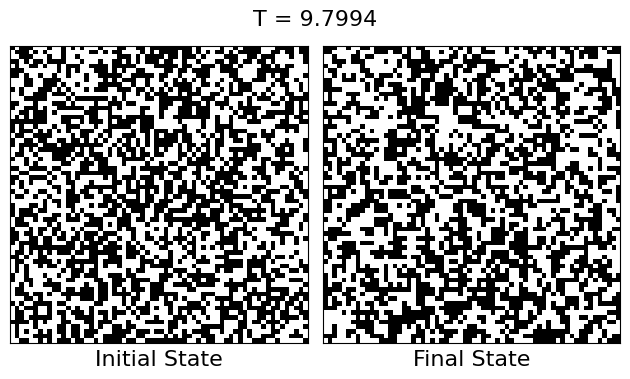

Temperature: 10.10530612244898


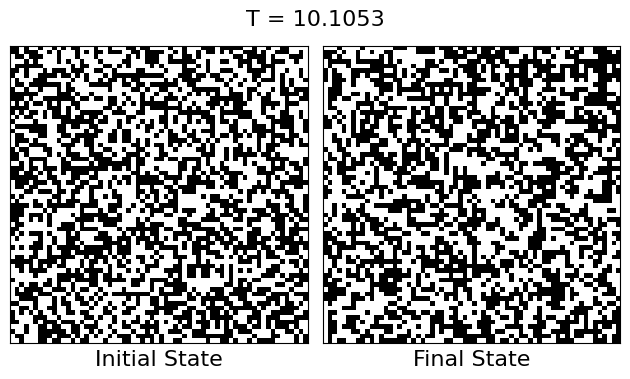

Temperature: 10.411224489795918


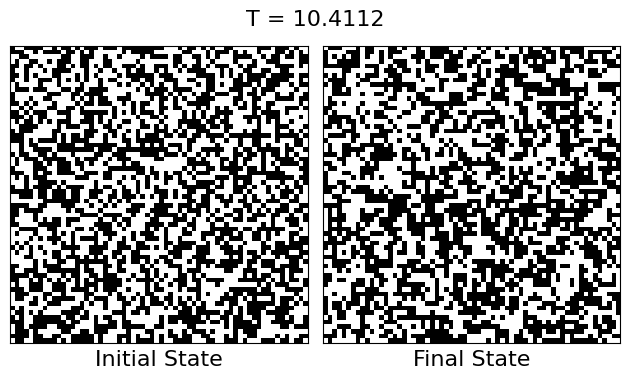

Temperature: 10.717142857142857


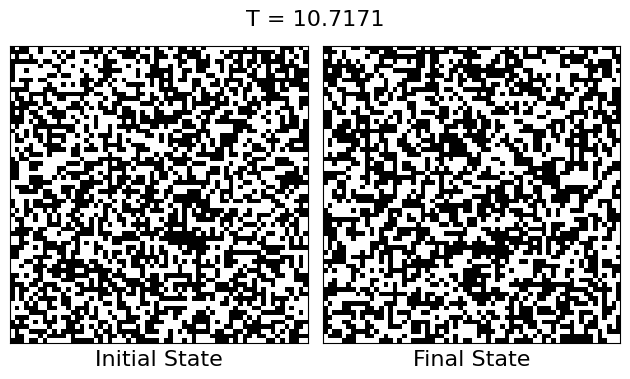

Temperature: 11.023061224489796


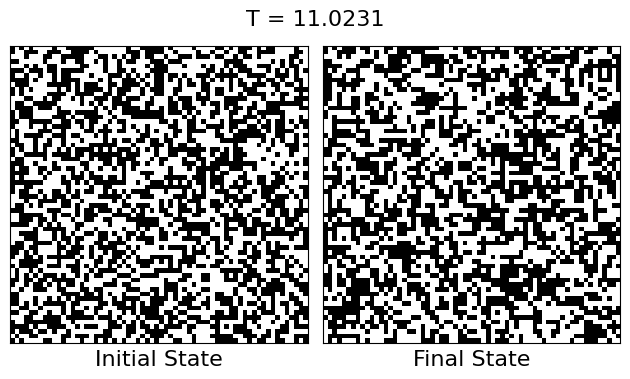

Temperature: 11.328979591836735


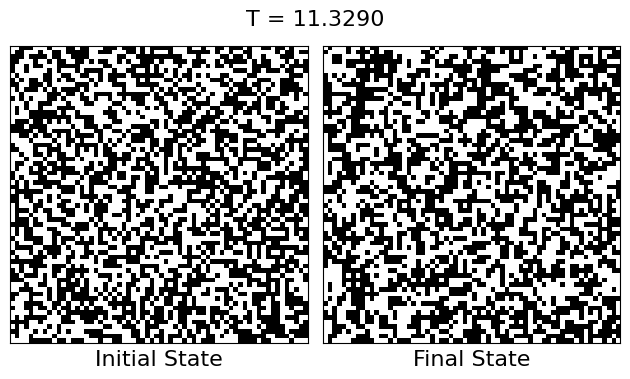

Temperature: 11.634897959183673


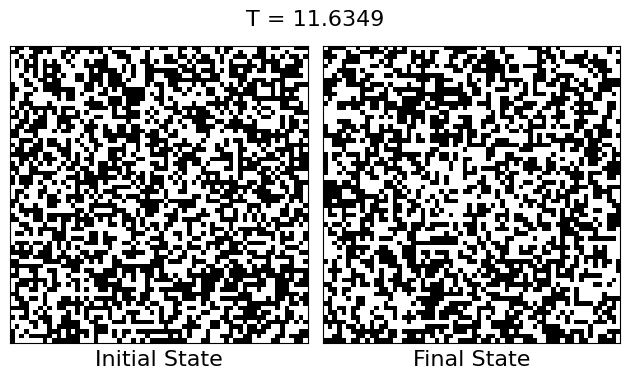

Temperature: 11.940816326530612


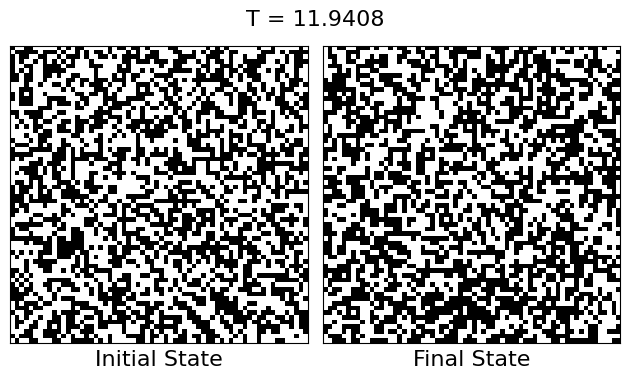

Temperature: 12.246734693877551


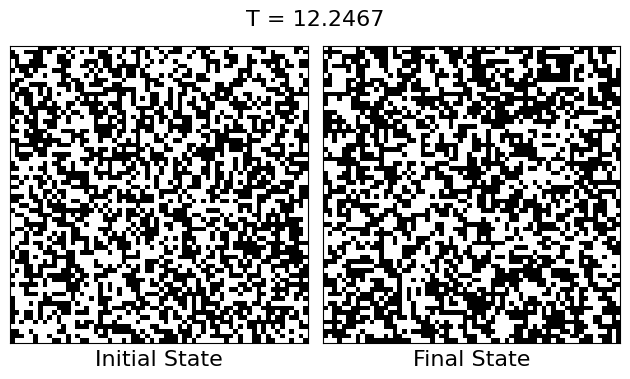

Temperature: 12.55265306122449


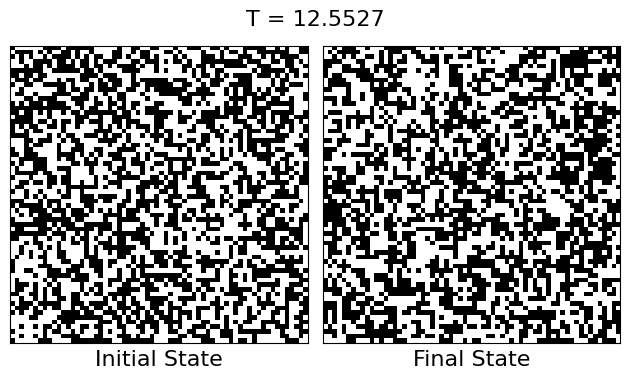

Temperature: 12.858571428571429


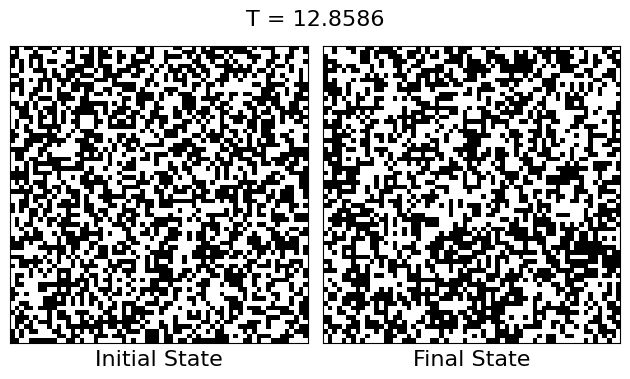

Temperature: 13.164489795918367


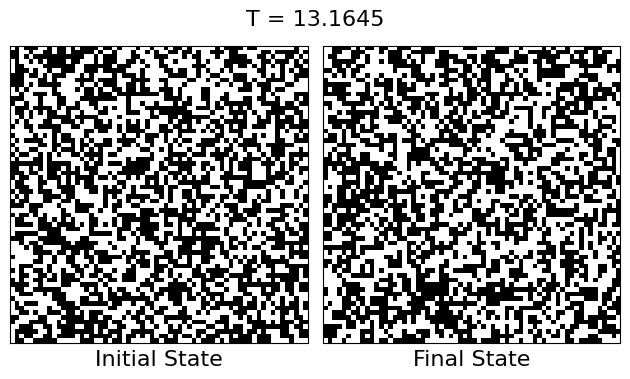

Temperature: 13.470408163265306


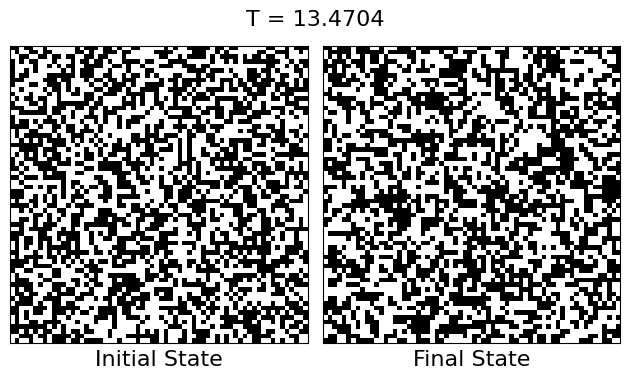

Temperature: 13.776326530612245


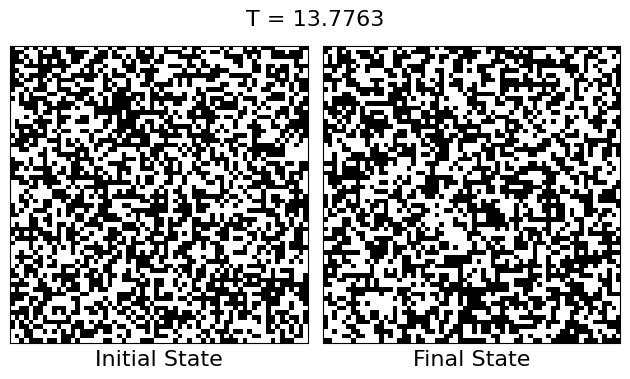

Temperature: 14.082244897959184


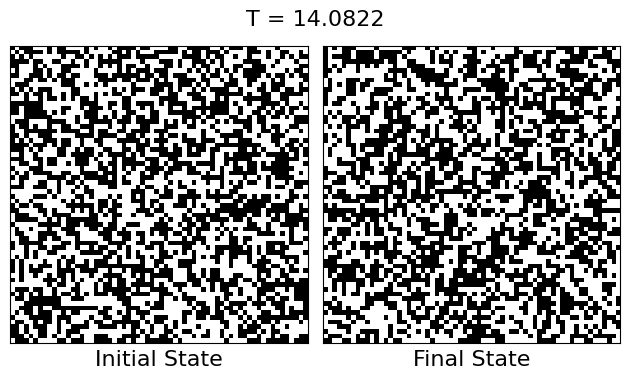

Temperature: 14.388163265306122


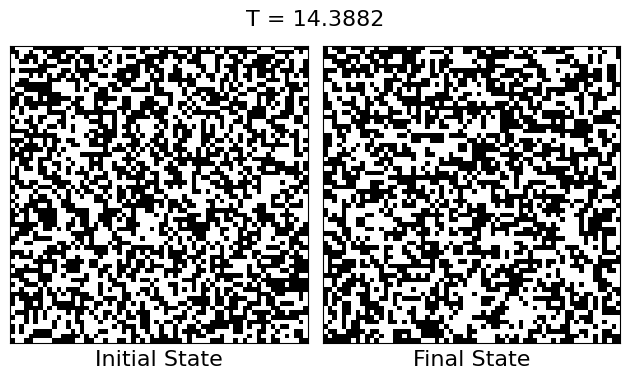

Temperature: 14.694081632653061


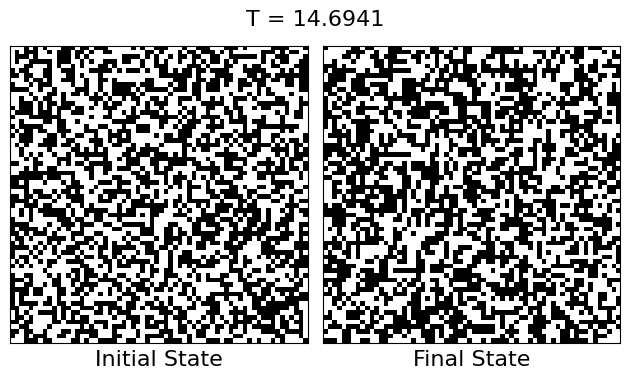

Temperature: 15.0


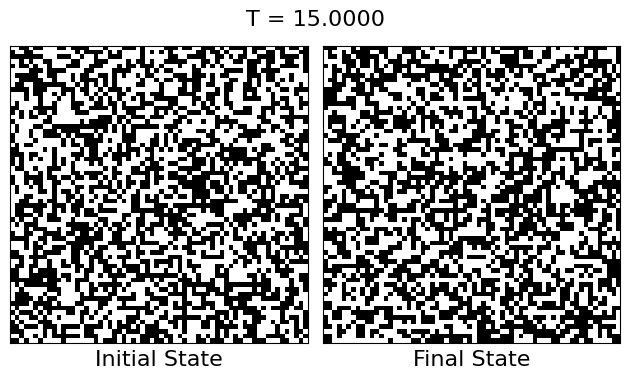

In [87]:
#Plot Spin Configurations
for i_T in range(Nt):
    print(f'Temperature: {Temps[i_T]}')
    f,ax = plt.subplots(1,2)
    ax[0].imshow(s_T[i_T][0],cmap='gray')
    ax[0].set_xticks([]);
    ax[0].set_yticks([]);
    ax[0].xaxis.set_label_position('bottom')
    ax[0].set_xlabel('Initial State',fontsize=16)
    ax[1].imshow(s_T[i_T][1],cmap='gray')
    ax[1].set_xticks([]);
    ax[1].set_yticks([]);   
    ax[1].xaxis.set_label_position('bottom')
    ax[1].set_xlabel('Final State',fontsize=16)
    f.suptitle(f'T = {Temps[i_T]:.4f}',y=.85,fontsize=16)
    plt.tight_layout()
    #plt.savefig(f'Figures/2D/2D-spinconfigplots/2Dconfig{i_T+1}.jpg')
    plt.show()